###**Project Title: Predictive Failure Analysis of Azure Virtual Machines**
####SUBMITTED TO
**Dr. Sadaf Abdul Rauf**

####Group members


1.   Amna Javed (009)
2.   Aqsa Fida (014)
3.   Mishal Raziq(064)
4.   Rabbia Noor(070)
5.   Saniya Rizwan(079)




 ###
 Semester VI-B


##Objective:
The goal of this project is to develop a predictive model that identifies potential failures in
Azure Virtual Machines (VMs) by analyzing patterns in resource usage data. By leveraging data
analytics and machine learning, we aim to reduce downtime, improve service reliability, and
optimize resource allocation.
##Problem Statement:
Azure VMs are critical components of cloud infrastructure, and unexpected failures can lead to
significant disruptions, financial losses, and degraded user experience. Proactive identification
of potential failures can help mitigate these issues.
#SECTION 1: Data collection
The Microsoft Azure Predictive Maintenance dataset on Kaggle provides five pre-formatted CSV files—telemetry, errors, failures, machines, and maintenance—for modeling, eliminating the need for a live environment. Utilizing this dataset requires loading, parsing datetimes, and merging the files, primarily using machineID and datetime keys for analysis. Download the dataset from Kaggle.
#link
 https://www.kaggle.com/datasets/arnabbiswas1/microsoft-azure-predictive-maintenance?resource=download
 ### Microsoft Azure Predictive Maintenance: Dataset Overview
 Predictive Maintenance (PdM) is an industrial strategy that uses data to fix machines just before they break, saving time and money compared to fixing them after they fail.
## The Dataset
This dataset mimics a real factory environment with 100(877210) machines. It provides:

* Telemetry: Hourly sensor readings (Voltage, Vibration, etc.).
* Errors: Logs of "warning" signs that don't stop the machine.
* Failures: The actual records of when a machine broke down (your target).
* Maintenance: History of past repairs and part swaps.
* Machines: Basic info like age and model type.

## The Goal
You use this data to build a model that predicts:

   1. If a machine will fail in the next 24 hours.
   2. Which specific component needs to be replaced.




### Predictive Maintenance (PdM) — Data Pipeline

This notebook processes the **Microsoft Azure Predictive Maintenance** dataset to engineer features suitable for training a failure-prediction model.

# SECTION 2: PREPROCESSING
### Step 1: Import Libraries
We import `pandas` for data manipulation and `numpy` for numerical operations.

In [ ]:
import pandas as pd
import numpy as np

### Step 2: Load Raw Data
We load five CSV files that represent different aspects of the predictive maintenance dataset:
- **Telemetry** — hourly sensor readings (volt, rotate, pressure, vibration)
- **Errors** — logged error events per machine
- **Maintenance** — scheduled and unscheduled component replacements
- **Failures** — records of actual component failures
- **Machines** — static machine metadata (model, age)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/Azure Vm Failure prediction project/"

telemetry = pd.read_csv(base_path + "PdM_telemetry.csv")
errors = pd.read_csv(base_path + "PdM_errors.csv")
maint = pd.read_csv(base_path + "PdM_maint.csv")
failures = pd.read_csv(base_path + "PdM_failures.csv")
machines = pd.read_csv(base_path + "PdM_machines.csv")

### Step 3: Data Audit
We define an `audit()` function to quickly inspect each dataframe — its shape, columns, missing values, duplicates, and a sample of rows. This gives us a bird's-eye view of data quality before any processing.

In [ ]:
def audit(df, name):
    print(f"\n{name}")
    print("-"*50)
    print("Shape:", df.shape)
    print("\nColumns:\n", df.columns)
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nDuplicates:", df.duplicated().sum())
    print("\nSample:\n", df.head())

audit(telemetry, "Telemetry")
audit(errors, "Errors")
audit(maint, "Maintenance")
audit(failures, "Failures")
audit(machines, "Machines")


Telemetry
--------------------------------------------------
Shape: (876100, 6)

Columns:
 Index(['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration'], dtype='object')

Missing Values:
 datetime     0
machineID    0
volt         0
rotate       0
pressure     0
vibration    0
dtype: int64

Duplicates: 0

Sample:
               datetime  machineID        volt      rotate    pressure  \
0  2015-01-01 06:00:00          1  176.217853  418.504078  113.077935   
1  2015-01-01 07:00:00          1  162.879223  402.747490   95.460525   
2  2015-01-01 08:00:00          1  170.989902  527.349825   75.237905   
3  2015-01-01 09:00:00          1  162.462833  346.149335  109.248561   
4  2015-01-01 10:00:00          1  157.610021  435.376873  111.886648   

   vibration  
0  45.087686  
1  43.413973  
2  34.178847  
3  41.122144  
4  25.990511  

Errors
--------------------------------------------------
Shape: (3919, 3)

Columns:
 Index(['datetime', 'machineID', 'errorID'], dtype='obj

### Step 4: Parse Datetime Columns
The `datetime` columns in telemetry, errors, maintenance, and failures are read as plain strings. We convert them to proper `datetime64` objects so we can perform time-based operations later.

In [ ]:
for df in [telemetry, errors, maint, failures]:
    df['datetime'] = pd.to_datetime(df['datetime'], format='mixed', errors='coerce')

### Step 5: Sort Data
All time-series dataframes are sorted by `machineID` and `datetime` in ascending order to ensure correct sequential ordering — a prerequisite for lag features and rolling windows.

In [ ]:
telemetry = telemetry.sort_values(['machineID', 'datetime'])
errors = errors.sort_values(['machineID', 'datetime'])
maint = maint.sort_values(['machineID', 'datetime'])
failures = failures.sort_values(['machineID', 'datetime'])

### Step 6: Verify Data Types
We print the data types of each dataframe to confirm that the datetime conversion worked correctly and that all other columns are of the expected types.

In [ ]:
print(telemetry.dtypes)
print(errors.dtypes)
print(maint.dtypes)
print(failures.dtypes)
print(machines.dtypes)

datetime     datetime64[ns]
machineID             int64
volt                float64
rotate              float64
pressure            float64
vibration           float64
dtype: object
datetime     datetime64[ns]
machineID             int64
errorID              object
dtype: object
datetime     datetime64[ns]
machineID             int64
comp                 object
dtype: object
datetime     datetime64[ns]
machineID             int64
failure              object
dtype: object
machineID     int64
model        object
age           int64
dtype: object


### Step 7: Statistical Summary of Telemetry




We use `.describe()` on the telemetry dataframe to check the range and distribution of each sensor reading. This helps identify potential outliers or physically impossible values.

In [ ]:
# Check for impossible values
print(telemetry.describe())

                  datetime      machineID           volt         rotate  \
count               876100  876100.000000  876100.000000  876100.000000   
mean   2015-07-02 18:00:00      50.500000     170.777736     446.605119   
min    2015-01-01 06:00:00       1.000000      97.333604     138.432075   
25%    2015-04-02 12:00:00      25.750000     160.304927     412.305714   
50%    2015-07-02 18:00:00      50.500000     170.607338     447.558150   
75%    2015-10-02 00:00:00      75.250000     181.004493     482.176600   
max    2016-01-01 06:00:00     100.000000     255.124717     695.020984   
std                    NaN      28.866087      15.509114      52.673886   

            pressure      vibration  
count  876100.000000  876100.000000  
mean      100.858668      40.385007  
min        51.237106      14.877054  
25%        93.498181      36.777299  
50%       100.425559      40.237247  
75%       107.555231      43.784938  
max       185.951998      76.791072  
std        11.048679

MEMBER 2: AQSA FIDA (014)
### Step 8: Visualize Sensor Distributions
A boxplot of the four sensor readings (volt, rotate, pressure, vibration) gives a visual summary of their spread, median, and outliers across all machines.

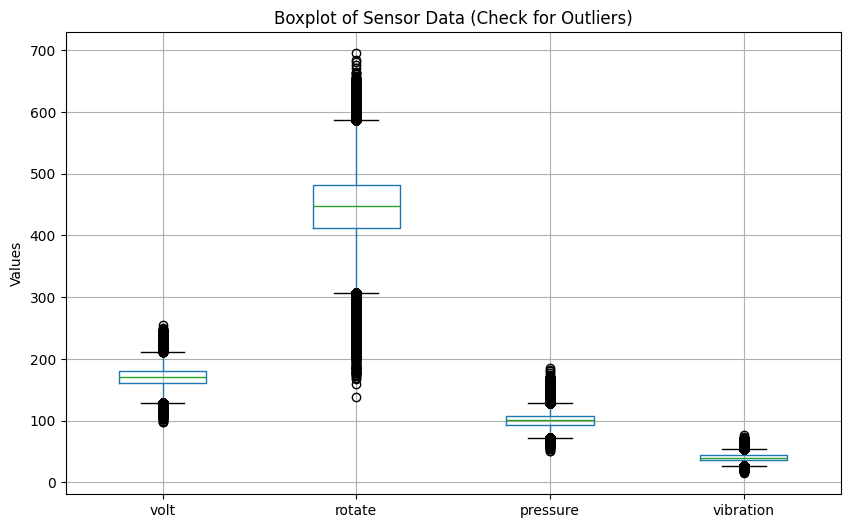

In [ ]:
import matplotlib.pyplot as plt

# Select only numeric columns (excluding machineID)
cols = ['volt', 'rotate', 'pressure', 'vibration']

plt.figure(figsize=(10,6))
telemetry[cols].boxplot()

plt.title("Boxplot of Sensor Data (Check for Outliers)")
plt.ylabel("Values")
plt.show()

## Cap extreme values
Capping is a technique where extreme values (outliers) are limited to a fixed boundary instead of being removed.

In [ ]:
# Columns to cap
cols = ['volt', 'rotate', 'pressure', 'vibration']

# Apply capping
for col in cols:
    lower = telemetry[col].quantile(0.01)   # 1% lower limit
    upper = telemetry[col].quantile(0.99)   # 99% upper limit

    telemetry[col] = telemetry[col].clip(lower, upper)

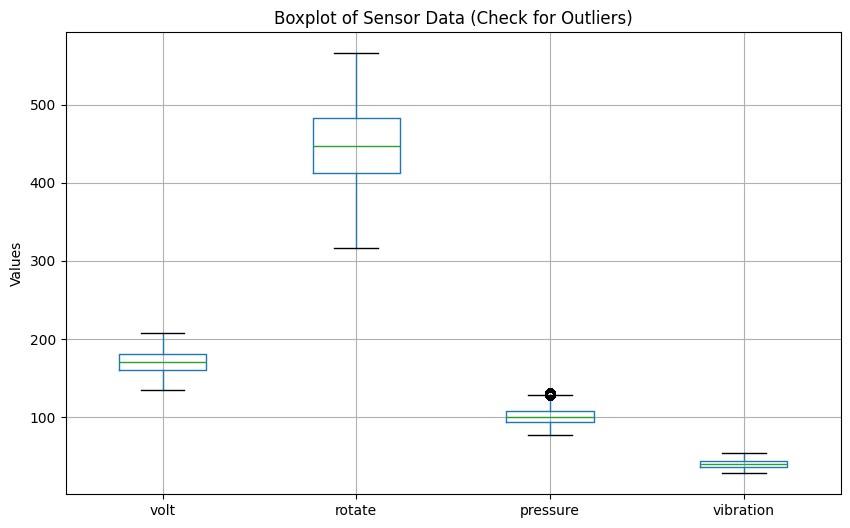

In [ ]:
import matplotlib.pyplot as plt

# Select only numeric columns (excluding machineID)
cols = ['volt', 'rotate', 'pressure', 'vibration']

plt.figure(figsize=(10,6))
telemetry[cols].boxplot()

plt.title("Boxplot of Sensor Data (Check for Outliers)")
plt.ylabel("Values")
plt.show()

### Step 9: Pivot Error Flags
Each row in the errors table represents one error event. We add a binary `error_flag` column and pivot the table so that each error type (`error1`–`error5`) becomes its own column, making it easy to merge with the telemetry data.

In [ ]:
errors['error_flag'] = 1

errors_pivot = errors.pivot_table(
    index=['machineID', 'datetime'],
    columns='errorID',
    values='error_flag',
    fill_value=0
).reset_index()

We inspect the resulting pivot table to verify its structure before merging.

In [ ]:
errors_pivot

errorID,machineID,datetime,error1,error2,error3,error4,error5
0,1,2015-01-03 07:00:00,1.0,0.0,0.0,0.0,0.0
1,1,2015-01-03 20:00:00,0.0,0.0,1.0,0.0,0.0
2,1,2015-01-04 06:00:00,0.0,0.0,0.0,0.0,1.0
3,1,2015-01-10 15:00:00,0.0,0.0,0.0,1.0,0.0
4,1,2015-01-22 10:00:00,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...
3611,100,2015-11-12 01:00:00,1.0,0.0,0.0,0.0,0.0
3612,100,2015-11-21 08:00:00,0.0,1.0,0.0,0.0,0.0
3613,100,2015-12-04 02:00:00,1.0,0.0,0.0,0.0,0.0
3614,100,2015-12-08 06:00:00,0.0,1.0,1.0,0.0,0.0


### Step 10: Pivot Maintenance Flags
Similarly, the maintenance records are pivoted so that each component (`comp1`–`comp4`) replacement becomes a separate binary column aligned by machine and datetime.

In [ ]:
maint['maint_flag'] = 1

maint_pivot = maint.pivot_table(
    index=['machineID', 'datetime'],
    columns='comp',
    values='maint_flag',
    fill_value=0
).reset_index()

We display the maintenance pivot table to confirm it looks correct.

In [ ]:
maint_pivot

comp,machineID,datetime,comp1,comp2,comp3,comp4
0,1,2014-06-01 06:00:00,0.0,1.0,0.0,0.0
1,1,2014-07-16 06:00:00,0.0,0.0,0.0,1.0
2,1,2014-07-31 06:00:00,0.0,0.0,1.0,0.0
3,1,2014-12-13 06:00:00,1.0,0.0,0.0,0.0
4,1,2015-01-05 06:00:00,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...
2523,100,2015-10-10 06:00:00,1.0,0.0,1.0,0.0
2524,100,2015-10-25 06:00:00,0.0,0.0,0.0,1.0
2525,100,2015-11-09 06:00:00,0.0,0.0,0.0,1.0
2526,100,2015-12-09 06:00:00,0.0,1.0,0.0,0.0


### Step 11: Add Failure Flag
We add a binary `failure_flag` column to the failures dataframe. This will serve as our **target label** (1 = failure, 0 = no failure) after merging.

In [ ]:
failures['failure_flag'] = 1

We preview the failures dataframe with the new flag column.

In [ ]:
failures

,datetime,machineID,failure,failure_flag
0,2015-01-05 06:00:00,1,comp4,1
1,2015-03-06 06:00:00,1,comp1,1
2,2015-04-20 06:00:00,1,comp2,1
3,2015-06-19 06:00:00,1,comp4,1
4,2015-09-02 06:00:00,1,comp4,1
...,...,...,...,...
756,2015-11-29 06:00:00,99,comp3,1
757,2015-12-14 06:00:00,99,comp4,1
758,2015-02-12 06:00:00,100,comp1,1
759,2015-09-10 06:00:00,100,comp1,1


### Step 12: Merge All Data Sources
We start from the telemetry dataframe (the backbone) and left-join all other sources on `machineID` and `datetime`. This creates one unified dataframe where each row is a telemetry reading enriched with error, maintenance, failure, and machine metadata.

In [ ]:
data = telemetry.copy()
data = data.merge(machines, on='machineID', how='left')
data = data.merge(errors_pivot, on=['machineID', 'datetime'], how='left')
data = data.merge(maint_pivot, on=['machineID', 'datetime'], how='left')
data = data.merge(
    failures[['machineID', 'datetime', 'failure_flag']],
    on=['machineID', 'datetime'],
    how='left'
)

We preview the first few rows of the merged dataframe to verify the join worked as expected.

In [ ]:
data.head(5)

,datetime,machineID,volt,rotate,pressure,vibration,model,age,error1,error2,error3,error4,error5,comp1,comp2,comp3,comp4,failure_flag
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,model3,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,model3,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01 08:00:00,1,170.989902,527.349825,76.845371,34.178847,model3,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,model3,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,28.446211,model3,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 13: Handle Missing Values
After merging, many rows will have `NaN` in error/maintenance/failure columns (meaning no event occurred at that timestamp). We fill all `NaN`s with `0` — a sensible default for binary event flags.

In [ ]:
data.fillna(0, inplace=True)

In [ ]:
data

,datetime,machineID,volt,rotate,pressure,vibration,model,age,error1,error2,error3,error4,error5,comp1,comp2,comp3,comp4,failure_flag
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,model3,18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,model3,18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2015-01-01 08:00:00,1,170.989902,527.349825,76.845371,34.178847,model3,18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,model3,18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,28.446211,model3,18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876137,2016-01-01 02:00:00,100,179.438162,395.222827,102.290715,50.771941,model4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
876138,2016-01-01 03:00:00,100,189.617555,446.207972,98.180607,35.123072,model4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
876139,2016-01-01 04:00:00,100,192.483414,447.816524,94.132837,48.314561,model4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
876140,2016-01-01 05:00:00,100,165.475310,413.771670,104.081073,44.835259,model4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Step 14: Remove Duplicate Rows
We drop any duplicate rows that may have been introduced during the merge to ensure data integrity.

In [ ]:
data.drop_duplicates(inplace=True)

### Step 15: Confirm No Missing Values Remain
We verify that all `NaN`s have been handled and no nulls remain in the dataset.

In [ ]:
print(data.isnull().sum())

datetime        0
machineID       0
volt            0
rotate          0
pressure        0
vibration       0
model           0
age             0
error1          0
error2          0
error3          0
error4          0
error5          0
comp1           0
comp2           0
comp3           0
comp4           0
failure_flag    0
dtype: int64


MEMBER 3: MISHAL RAZIQ (064)
# Feature Engineering:

where we create new meaningful features that help the model understand patterns leading to machine failure.

### Step 16: Extract Time-Based Features
We extract temporal features from the `datetime` column — **hour**, **day**, **month**, and **day of week**.
These help the model learn cyclical patterns (e.g., failures more likely on certain shifts or days).

In [ ]:
# Extract time-based features from datetime

data['hour'] = data['datetime'].dt.hour
data['day'] = data['datetime'].dt.day
data['month'] = data['datetime'].dt.month
data['dayofweek'] = data['datetime'].dt.dayofweek

# Print sample to verify
print(data[['datetime','hour','day','month','dayofweek']].sample(5))

                  datetime  hour  day  month  dayofweek
829295 2015-08-27 16:00:00    16   27      8          3
798574 2015-02-23 20:00:00    20   23      2          0
510516 2015-04-09 04:00:00     4    9      4          3
583089 2015-07-21 14:00:00    14   21      7          1
819024 2015-06-25 19:00:00    19   25      6          3


### Step 17: Create Lag Features
Lag features capture the sensor values from the **previous hour** for each machine. This allows the model to detect sudden changes in sensor readings that may precede a failure.

In [ ]:
# Create lag features (previous hour values)

data = data.sort_values(['machineID', 'datetime'])

data['volt_lag1'] = data.groupby('machineID')['volt'].shift(1)
data['rotate_lag1'] = data.groupby('machineID')['rotate'].shift(1)
data['pressure_lag1'] = data.groupby('machineID')['pressure'].shift(1)
data['vibration_lag1'] = data.groupby('machineID')['vibration'].shift(1)

# Print to verify lag values
print(data[['machineID','volt','volt_lag1','rotate', 'rotate_lag1','pressure','pressure_lag1','vibration','vibration_lag1']].sample(5))

        machineID        volt   volt_lag1      rotate  rotate_lag1  \
148223         17  183.291236  154.342579  384.763114   484.171996   
269713         31  139.814673  180.344957  416.038145   415.514489   
294220         34  184.899532  170.359014  439.965390   496.105233   
657227         76  181.175525  164.877084  449.692398   523.049947   
711060         82  186.460787  167.788979  503.370496   445.964360   

          pressure  pressure_lag1  vibration  vibration_lag1  
148223  111.516632      96.161558  44.119946       40.394115  
269713  112.231690      94.101126  31.300962       41.161285  
294220   97.182226      93.907384  36.141705       37.090595  
657227  110.037863     114.828819  45.485278       30.840467  
711060   81.679323      85.026952  38.306397       38.675132  


### Step 18: Create Rolling Mean Features
We compute a 3-hour rolling mean for voltage and rotation speed per machine.Unlike simple mean, rolling mean captures short-term trends and smooths noise. This helps the model identify consistent patterns instead of sudden spikes.”

 “We applied it on important sensors like voltage and rotation to capture stable behavior trends.”

In [ ]:
# Create rolling mean (last 3 hours average)

data['volt_mean_3'] = data.groupby('machineID')['volt'].rolling(3).mean().reset_index(0, drop=True)
data['rotate_mean_3'] = data.groupby('machineID')['rotate'].rolling(3).mean().reset_index(0, drop=True)

# Print to verify rolling mean
print(data[['machineID','volt','volt_mean_3','rotate_mean_3']].sample(10))

        machineID        volt  volt_mean_3  rotate_mean_3
801351         92  171.335381   179.490478     442.118639
125756         15  166.097627   166.121313     403.211117
750386         86  161.481126   161.999585     454.802904
118004         14  180.143401   175.810845     433.587428
356685         41  172.911909   172.509269     476.964107
311972         36  174.878181   167.809179     411.369323
358667         41  146.835873   152.382136     441.273414
128753         15  164.976946   161.592787     465.125659
114957         14  184.758056   164.013048     494.291851
351095         41  167.061486   164.871599     356.286195


### Step 19: Create Maintenance Features
We create two maintenance-related features:
- `is_maint` —  → Was maintenance done now? (0 or 1)

- `time_since_last_maint` — How much time passed since last repair

In [ ]:
# Create maintenance features
# Step 1: Mark if maintenance happened
data['is_maint'] = (data[['comp1','comp2','comp3','comp4']].sum(axis=1) > 0).astype(int)

# Step 2: Store last maintenance time
data['last_maint_time'] = data['datetime'].where(data['is_maint'] == 1)

# Step 3: Fill last maintenance time forward
data['last_maint_time'] = data.groupby('machineID')['last_maint_time'].ffill()

# Step 4: Calculate time since last maintenance
data['time_since_last_maint'] = (data['datetime'] - data['last_maint_time']).dt.total_seconds()

# Print to verify
print(data[['datetime','is_maint','last_maint_time','time_since_last_maint']].sample(10))

                  datetime  is_maint     last_maint_time  \
485921 2015-06-18 13:00:00         0 2015-06-13 06:00:00   
267364 2015-07-08 09:00:00         0 2015-07-06 06:00:00   
442557 2015-07-07 00:00:00         0 2015-06-30 06:00:00   
356848 2015-09-24 06:00:00         0 2015-09-14 06:00:00   
114305 2015-01-18 03:00:00         0 2015-01-16 06:00:00   
646702 2015-10-24 19:00:00         0 2015-10-20 06:00:00   
654748 2015-09-25 00:00:00         0 2015-09-19 06:00:00   
463180 2015-11-13 03:00:00         0 2015-11-09 06:00:00   
306074 2015-12-07 23:00:00         0 2015-12-02 06:00:00   
489325 2015-11-07 08:00:00         0 2015-10-26 06:00:00   

        time_since_last_maint  
485921               457200.0  
267364               183600.0  
442557               583200.0  
356848               864000.0  
114305               162000.0  
646702               392400.0  
654748               496800.0  
463180               334800.0  
306074               493200.0  
489325             

### Step 20: Drop Rows with Remaining NaNs
After computing lag and rolling features, the first few rows per machine will have `NaN` values (no prior data to look back on). We drop these incomplete rows.

In [ ]:
# BEFORE: Check missing values
print("Missing values BEFORE:")
print(data.isnull().sum())

# Remove NaN rows
data = data.dropna()

# AFTER: Check again
print("\nMissing values AFTER:")
print(data.isnull().sum())

Missing values BEFORE:
datetime                     0
machineID                    0
volt                         0
rotate                       0
pressure                     0
vibration                    0
model                        0
age                          0
error1                       0
error2                       0
error3                       0
error4                       0
error5                       0
comp1                        0
comp2                        0
comp3                        0
comp4                        0
failure_flag                 0
hour                         0
day                          0
month                        0
dayofweek                    0
volt_lag1                  100
rotate_lag1                100
pressure_lag1              100
vibration_lag1             100
volt_mean_3                200
rotate_mean_3              200
is_maint                     0
last_maint_time          36000
time_since_last_maint    36000
dtype: int64

Mi

### Step 21: Check Class Balance
We inspect the distribution of the target variable `failure_flag`. This is critical — PdM datasets are typically highly imbalanced (far more non-failure hours than failure hours).

In [ ]:
print(data['failure_flag'].value_counts())

failure_flag
0.0    839381
1.0       705
Name: count, dtype: int64


### Step 22: Final Data Summary
“Finally, we reviewed the dataset using head, and statistical summary. This helps us confirm that our data is clean, structured, and ready for modeling. It also gives insights about average values, ranges, and overall data distribution.”

In [ ]:
print(data.head())
print(data.describe())

               datetime  machineID        volt      rotate    pressure  \
96  2015-01-05 06:00:00          1  179.303153  499.777962  111.833028   
97  2015-01-05 07:00:00          1  155.511452  498.398435  103.068134   
98  2015-01-05 08:00:00          1  172.439821  392.124959  108.135159   
99  2015-01-05 09:00:00          1  138.826437  451.348967  126.464580   
100 2015-01-05 10:00:00          1  177.278402  403.199389  100.858613   

     vibration   model  age  error1  error2  ...  dayofweek   volt_lag1  \
96   52.383097  model3   18     0.0     0.0  ...          0  177.510419   
97   33.270415  model3   18     0.0     0.0  ...          0  179.303153   
98   39.477497  model3   18     0.0     0.0  ...          0  155.511452   
99   38.257462  model3   18     0.0     0.0  ...          0  172.439821   
100  38.776021  model3   18     0.0     0.0  ...          0  138.826437   

     rotate_lag1  pressure_lag1  vibration_lag1  volt_mean_3  rotate_mean_3  \
96    469.787301     100.

“This dataset contains over 840,000 hourly machine records. Each row represents sensor readings of a machine at a specific time. From statistical summary, we observe that sensor values are stable and within normal ranges. Failures and maintenance events are very rare, making the dataset highly imbalanced. Also, time-based features like time since last maintenance vary significantly, which is important for predicting machine failure.

MEMBER 4: RABBIA NOOR (070)

### Step 23: One-Hot Encode Machine Model
The categorical `model` column (model1–model4) is encoded into binary dummy variables using `pd.get_dummies()`, dropping the first category to avoid multicollinearity.

In [ ]:
data = pd.get_dummies(data, columns=['model'], drop_first=True)

### Step 24: Cast Boolean Columns to Integer
The one-hot encoded model columns are cast from boolean to integer (`0`/`1`) to ensure compatibility with downstream ML libraries.

In [ ]:
cols = ['model_model2', 'model_model3', 'model_model4']

data[cols] = data[cols].astype(int)

### Step 25: Drop Intermediate Columns
The `last_maint_time` column was used as an intermediate step to compute `time_since_last_maint`. Now that the derived feature is ready, we drop the raw datetime column.

In [ ]:
data = data.drop(['last_maint_time'], axis=1)

### Step 26: Finalise Target Column
We ensure the `failure_flag` column has no remaining `NaN`s and is stored as an integer type — ready to be used as the classification target.

In [ ]:
data['failure_flag'] = data['failure_flag'].fillna(0).astype(int)

### Step 27: Verify Final Data Types
We confirm the data types of all columns in the final dataframe. All features should be numeric (`int64` or `float64`) and `datetime` should remain as `datetime64[ns]`.

In [ ]:
data.dtypes

,0
datetime,datetime64[ns]
machineID,int64
volt,float64
rotate,float64
pressure,float64
vibration,float64
age,int64
error1,float64
error2,float64
error3,float64


### Step 28: Export Engineered Dataset
The fully processed and feature-engineered dataframe is saved to `azure_vm_predictive_data.csv`. This file can be used directly for training predictive maintenance models.

In [ ]:
data.to_csv("azure_vm_predictive_data.csv", index=False)

In [ ]:
data

,datetime,machineID,volt,rotate,pressure,vibration,age,error1,error2,error3,...,rotate_lag1,pressure_lag1,vibration_lag1,volt_mean_3,rotate_mean_3,is_maint,time_since_last_maint,model_model2,model_model3,model_model4
96,2015-01-05 06:00:00,1,179.303153,499.777962,111.833028,52.383097,18,0.0,0.0,0.0,...,469.787301,100.498426,54.240628,186.444687,452.190194,1,0.0,0,1,0
97,2015-01-05 07:00:00,1,155.511452,498.398435,103.068134,33.270415,18,0.0,0.0,0.0,...,499.777962,111.833028,52.383097,170.775008,489.321233,0,3600.0,0,1,0
98,2015-01-05 08:00:00,1,172.439821,392.124959,108.135159,39.477497,18,0.0,0.0,0.0,...,498.398435,103.068134,33.270415,169.084809,463.433785,0,7200.0,0,1,0
99,2015-01-05 09:00:00,1,138.826437,451.348967,126.464580,38.257462,18,0.0,0.0,0.0,...,392.124959,108.135159,39.477497,155.592570,447.290787,0,10800.0,0,1,0
100,2015-01-05 10:00:00,1,177.278402,403.199389,100.858613,38.776021,18,0.0,0.0,0.0,...,451.348967,126.464580,38.257462,162.848220,415.557772,0,14400.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876137,2016-01-01 02:00:00,100,179.438162,395.222827,102.290715,50.771941,5,0.0,0.0,0.0,...,481.253908,101.589735,44.382754,170.306956,438.653616,0,676800.0,0,0,1
876138,2016-01-01 03:00:00,100,189.617555,446.207972,98.180607,35.123072,5,0.0,0.0,0.0,...,395.222827,102.290715,50.771941,177.266129,440.894903,0,680400.0,0,0,1
876139,2016-01-01 04:00:00,100,192.483414,447.816524,94.132837,48.314561,5,0.0,0.0,0.0,...,446.207972,98.180607,35.123072,187.179710,429.749108,0,684000.0,0,0,1
876140,2016-01-01 05:00:00,100,165.475310,413.771670,104.081073,44.835259,5,0.0,0.0,0.0,...,447.816524,94.132837,48.314561,182.525427,435.932056,0,687600.0,0,0,1


#Section 3: Analyzing System Metrics to Identify Failure Patterns

Import Libraries

In [ ]:
# We import required libraries:
# pandas → for data handling
# matplotlib & seaborn → for visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Final Cleaned Dataset

In [ ]:
# Load the dataset that was created after preprocessing (Step 2)

data = pd.read_csv("azure_vm_predictive_data.csv")

Basic Check

In [ ]:
# Check number of rows & columns
print(data.shape)

# Preview first few rows to understand structure
print(data.head())

(840086, 32)
              datetime  machineID        volt      rotate    pressure  \
0  2015-01-05 06:00:00          1  179.303153  499.777962  111.833028   
1  2015-01-05 07:00:00          1  155.511452  498.398435  103.068134   
2  2015-01-05 08:00:00          1  172.439821  392.124959  108.135159   
3  2015-01-05 09:00:00          1  138.826437  451.348967  126.464580   
4  2015-01-05 10:00:00          1  177.278402  403.199389  100.858613   

   vibration  age  error1  error2  error3  ...  rotate_lag1  pressure_lag1  \
0  52.383097   18     0.0     0.0     0.0  ...   469.787301     100.498426   
1  33.270415   18     0.0     0.0     0.0  ...   499.777962     111.833028   
2  39.477497   18     0.0     0.0     0.0  ...   498.398435     103.068134   
3  38.257462   18     0.0     0.0     0.0  ...   392.124959     108.135159   
4  38.776021   18     0.0     0.0     0.0  ...   451.348967     126.464580   

   vibration_lag1  volt_mean_3  rotate_mean_3  is_maint  \
0       54.240628   

# **CORE ANALYSIS**

3.1: CPU (Voltage) vs Failure

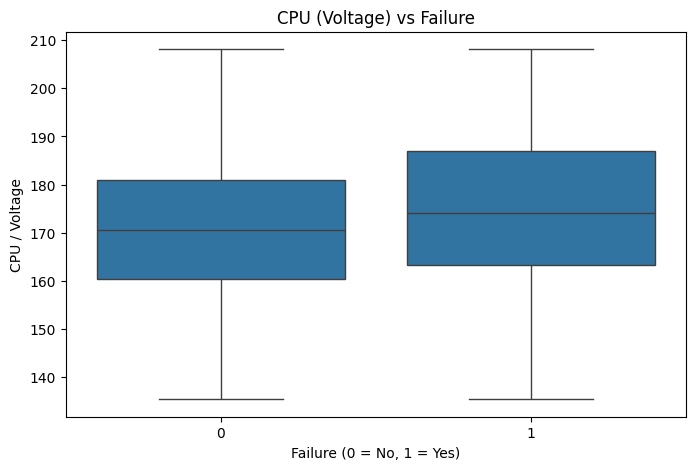

In [ ]:
# Boxplot compares CPU (volt) values for failure vs non-failure

plt.figure(figsize=(8,5))
sns.boxplot(x='failure_flag', y='volt', data=data)

plt.title("CPU (Voltage) vs Failure")
plt.xlabel("Failure (0 = No, 1 = Yes)")
plt.ylabel("CPU / Voltage")
plt.show()

3.2: Rotation vs Failure

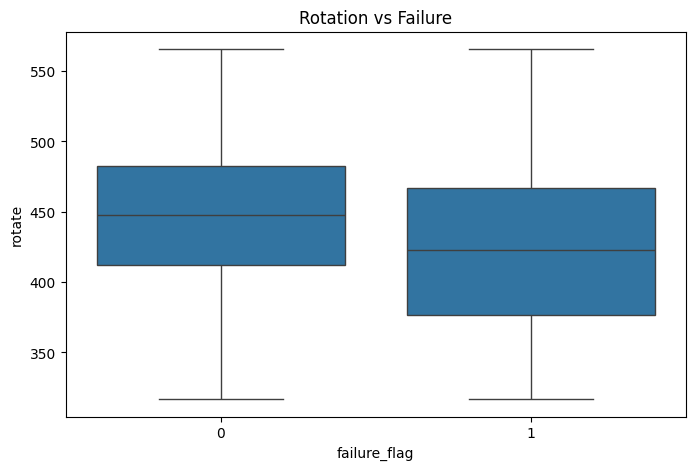

In [ ]:
# Boxplot for rotation vs failure

plt.figure(figsize=(8,5))
sns.boxplot(x='failure_flag', y='rotate', data=data)

plt.title("Rotation vs Failure")
plt.show()

## Activity
Draw a scatter graph between voltage and rotation and highlight failures.

3.3: Pressure vs Failure

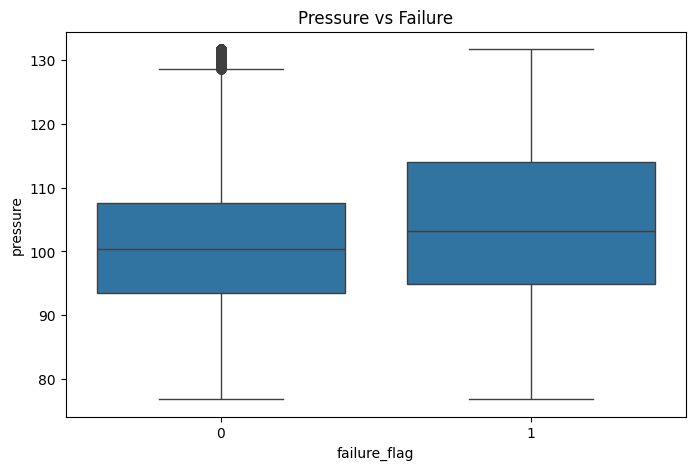

In [ ]:
# Boxplot for pressure vs failure

plt.figure(figsize=(8,5))
sns.boxplot(x='failure_flag', y='pressure', data=data)

plt.title("Pressure vs Failure")
plt.show()

3.4: Vibration vs Failure

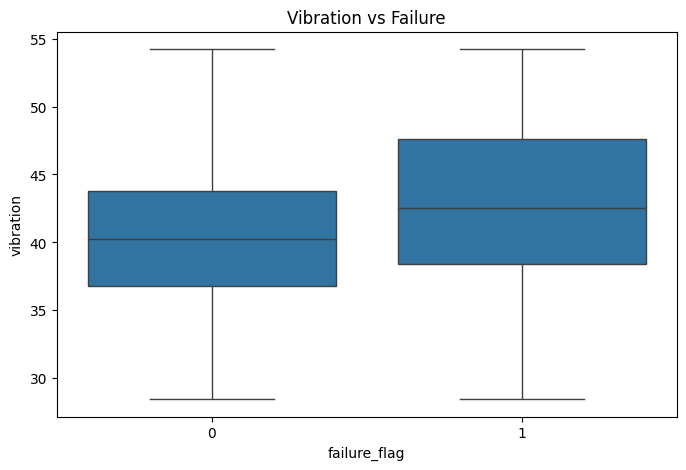

In [ ]:
# Boxplot for vibration vs failure

plt.figure(figsize=(8,5))
sns.boxplot(x='failure_flag', y='vibration', data=data)

plt.title("Vibration vs Failure")
plt.show()

3.5: Scatter Plot (Relationship View)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


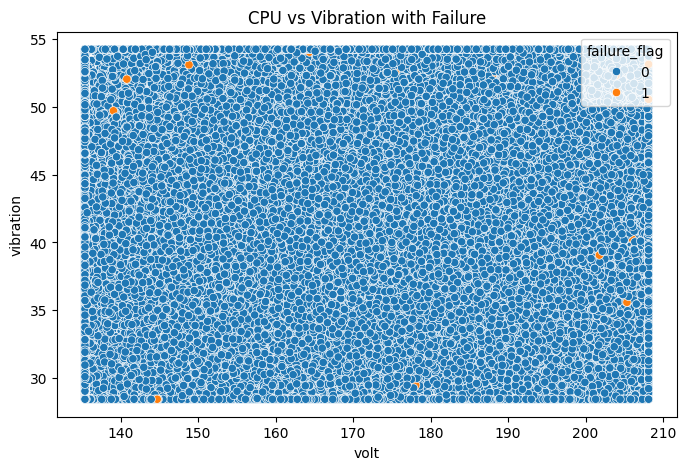

In [ ]:
# Scatter plot shows relationship between CPU and vibration
# Color represents failure or no failure

plt.figure(figsize=(8,5))
sns.scatterplot(x='volt', y='vibration', hue='failure_flag', data=data)

plt.title("CPU vs Vibration with Failure")
plt.show()

# Analyzing Sensor Behavior (Boxplots & Scatter Plots)
By looking at the boxplots and scatter plots, we can see a clear difference in how the machine behaves during a failure compared to normal operation. When a failure occurs, the Voltage, Pressure, and Vibration levels clearly shift higher, showing that the machine is under extreme stress and shaking more than usual. At the same time, the Rotation speed drops, which tells us the machine is struggling to keep up its normal pace. The scatter plot further shows that failures (orange dots) often happen when these sensor readings hit extreme levels.

**Key Takeaway:** The data proves that a failing machine "shouts" its trouble through **high vibration and slow rotation**, giving us the perfect warning signs to predict a breakdown.

3.6: Correlation Heatmap

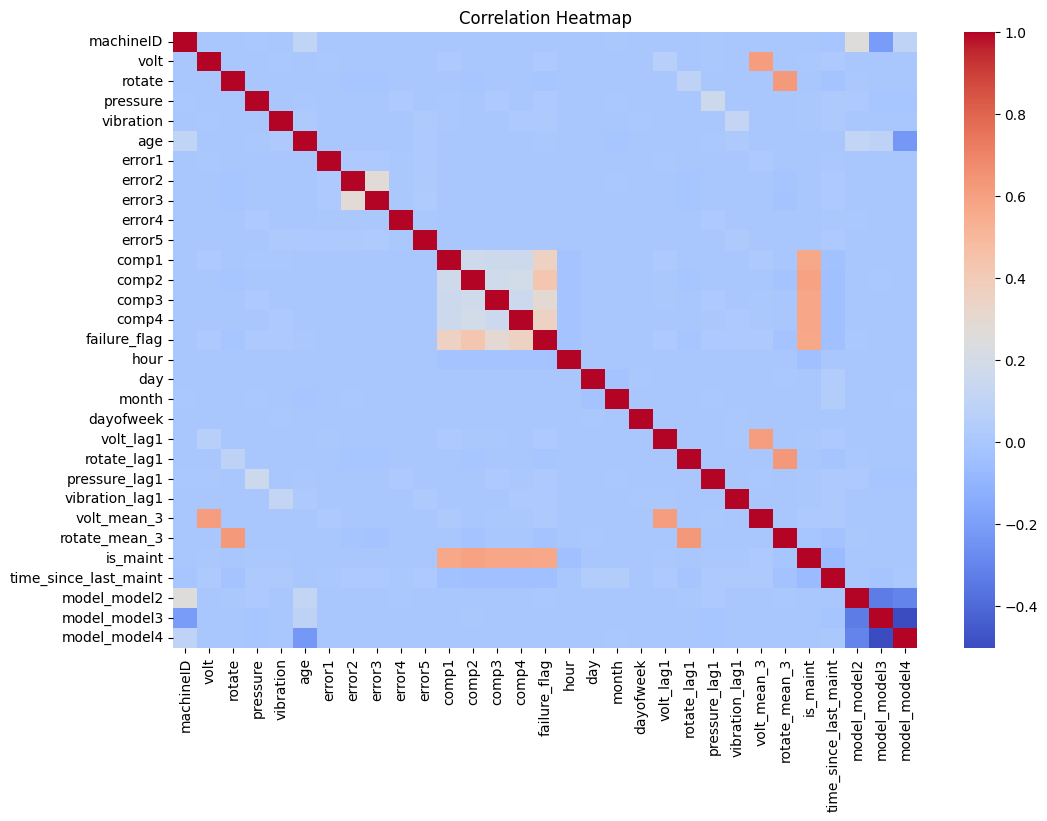

In [ ]:
# Correlation heatmap shows relationship between all numeric features
# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))

corr = numeric_data.corr()

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()


The correlation heatmap provides a comprehensive overview of the relationships between all numerical features in the dataset. It shows that features derived from the same variables, such as lag features (`volt_lag1`, `rotate_lag1`) and rolling means (`volt_mean_3`, `rotate_mean_3`), have strong positive correlations with their original sensor values, which is expected since they represent past and smoothed versions of the same measurements. The heatmap also indicates that maintenance-related features like `is_maint` and `time_since_last_maint` have noticeable relationships with component variables (`comp1–comp4`), suggesting that maintenance activities are linked to component behavior. Additionally, the failure flag shows meaningful correlations with certain components and sensor-based features, implying that these variables can help in predicting machine failures. The presence of both positive and negative correlations highlights how some features move together while others behave inversely.

**Interestingly, the raw sensor data (volt, rotate, pressure, vibration) and their lagged versions show very weak linear correlations with failure, implying that a failure isn't caused by a single high sensor reading at one moment, but rather by complex, non-linear patterns over time**

Overall, the graph concludes that there are several interrelated features in the dataset, and certain sensor readings, maintenance indicators, and component variables are more influential in identifying machine failures, making them valuable for predictive modeling.


3.7: Mean Comparison

This shows average sensor values when:

failure = 0 (normal)
failure = 1 (failure)


In [ ]:
# Calculate average values of sensors for failure and non-failure

failure_analysis = data.groupby('failure_flag')[['volt','rotate','pressure','vibration']].mean()

print(failure_analysis)

                    volt      rotate    pressure  vibration
failure_flag                                               
0             170.753297  446.723767  100.821497  40.372602
1             174.940130  422.813509  105.003278  42.946900


This table shows us exactly how a machine "acts" differently when failure hits. By comparing the numbers, we can see a very clear pattern.


*   **Voltage, Pressure, and Vibration go UP**: When the machine is
failing, it works harder and shakes more.

*  **Rotation goes DOWN:** The machine slows down. It can't spin as fast as it normally does because something is broken or stuck inside.

**Key Takeaway:** “Machine failure is characterized by high stress (voltage & pressure), high instability (vibration), and reduced performance (rotation).”

# Section 4: Large-Scale Data Analysis

In this section we dig deep into the 840,000+ rows of engineered data.  
Goal: **understand when, why, and how machines fail** — before we build any model.

We will cover:
- 4.1 Load Data & Quick Recap
- 4.2 Failure Distribution
- 4.3 Which Machines Fail the Most?
- 4.4 Failure Patterns Over Time (Month & Hour)
- 4.5 Sensor Behaviour in the Hours Before Failure
- 4.6 Time Since Last Maintenance vs Failure
- 4.7 Failure Rate by Machine Model
- 4.8 Which Component Fails Most?
- 4.9 Error Frequency Before Failure
- 4.10 Full Correlation Deep-Dive on Failure-Related Features
- 4.11 Summary of Key Findings

## Step 4.1 — Load Data & Quick Recap
We load the final engineered dataset from Step 2 and do a quick sanity check.

In [ ]:
data = pd.read_csv("azure_vm_predictive_data.csv")

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (840086, 32)


,datetime,machineID,volt,rotate,pressure,vibration,age,error1,error2,error3,...,rotate_lag1,pressure_lag1,vibration_lag1,volt_mean_3,rotate_mean_3,is_maint,time_since_last_maint,model_model2,model_model3,model_model4
0,2015-01-05 06:00:00,1,179.303153,499.777962,111.833028,52.383097,18,0.0,0.0,0.0,...,469.787301,100.498426,54.240628,186.444687,452.190194,1,0.0,0,1,0
1,2015-01-05 07:00:00,1,155.511452,498.398435,103.068134,33.270415,18,0.0,0.0,0.0,...,499.777962,111.833028,52.383097,170.775008,489.321233,0,3600.0,0,1,0
2,2015-01-05 08:00:00,1,172.439821,392.124959,108.135159,39.477497,18,0.0,0.0,0.0,...,498.398435,103.068134,33.270415,169.084809,463.433785,0,7200.0,0,1,0
3,2015-01-05 09:00:00,1,138.826437,451.348967,126.464580,38.257462,18,0.0,0.0,0.0,...,392.124959,108.135159,39.477497,155.592570,447.290787,0,10800.0,0,1,0
4,2015-01-05 10:00:00,1,177.278402,403.199389,100.858613,38.776021,18,0.0,0.0,0.0,...,451.348967,126.464580,38.257462,162.848220,415.557772,0,14400.0,0,1,0


## STEP 4.2: Failure Distribution (Basic Insight)

Question: Is data imbalanced?

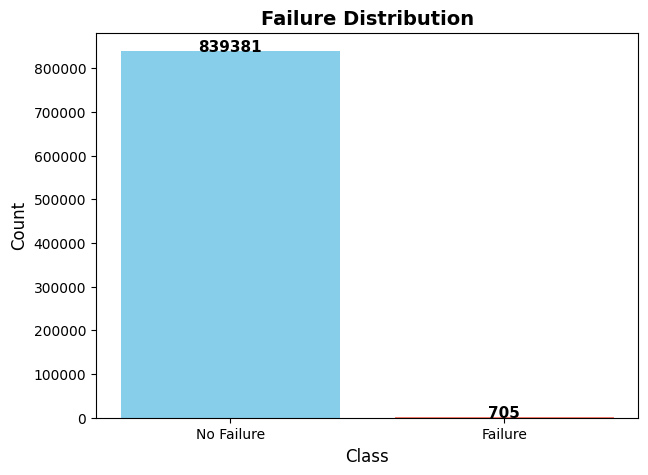

In [ ]:

# Count values
counts = data['failure_flag'].value_counts().sort_index()

labels = ['No Failure', 'Failure']
values = counts.values

plt.figure(figsize=(7,5))

# Add colors
colors = ['skyblue', 'salmon']

bars = plt.bar(labels, values, color=colors)

# Add counts on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 5,
             f'{int(height)}',
             ha='center', fontsize=11, fontweight='bold')

# Titles and labels
plt.title("Failure Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Class", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Improve layout
plt.grid(False)

plt.show()

## Step 4.3 Which Individual Machines Fail the Most?
**Question**: Are failures spread evenly across all 100 machines, or do some machines fail much more?
High-failing machines may need priority attention or early replacement.

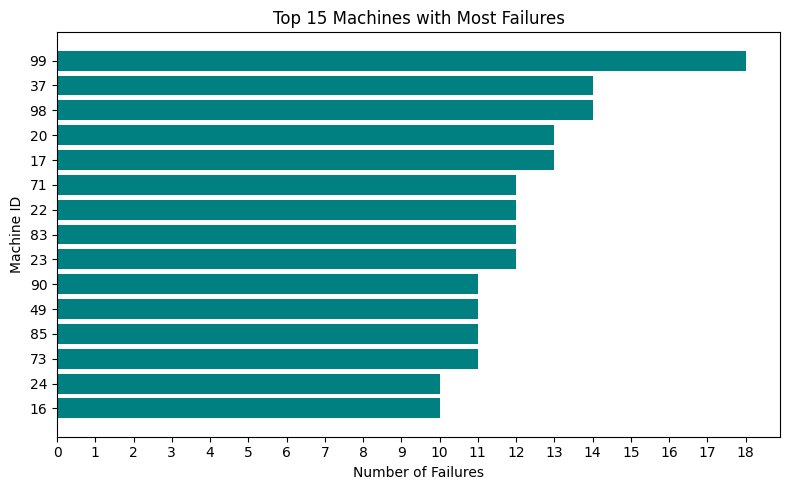

In [ ]:


# Group data
machine_failures = data.groupby('machineID')['failure_flag'].sum().sort_values(ascending=False)

# Top 15
top15 = machine_failures.head(15)

# Plot
plt.figure(figsize=(8,5))
bars = plt.barh(top15.index.astype(str), top15.values, color='teal')

# X-axis as integers (no decimals)
plt.xticks(range(0, int(top15.values.max()) + 1))

# # Add labels on bars
# for i, v in enumerate(top15.values):
#     plt.text(v, i, str(int(v)), va='center')

plt.title("Top 15 Machines with Most Failures")
plt.xlabel("Number of Failures")
plt.ylabel("Machine ID")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Step 4.4 Failure Patterns Over Time (Month & Hour of Day)
**Question**: Do failures happen more in certain months or at certain hours?
Knowing when failures cluster helps us schedule preventive checks.

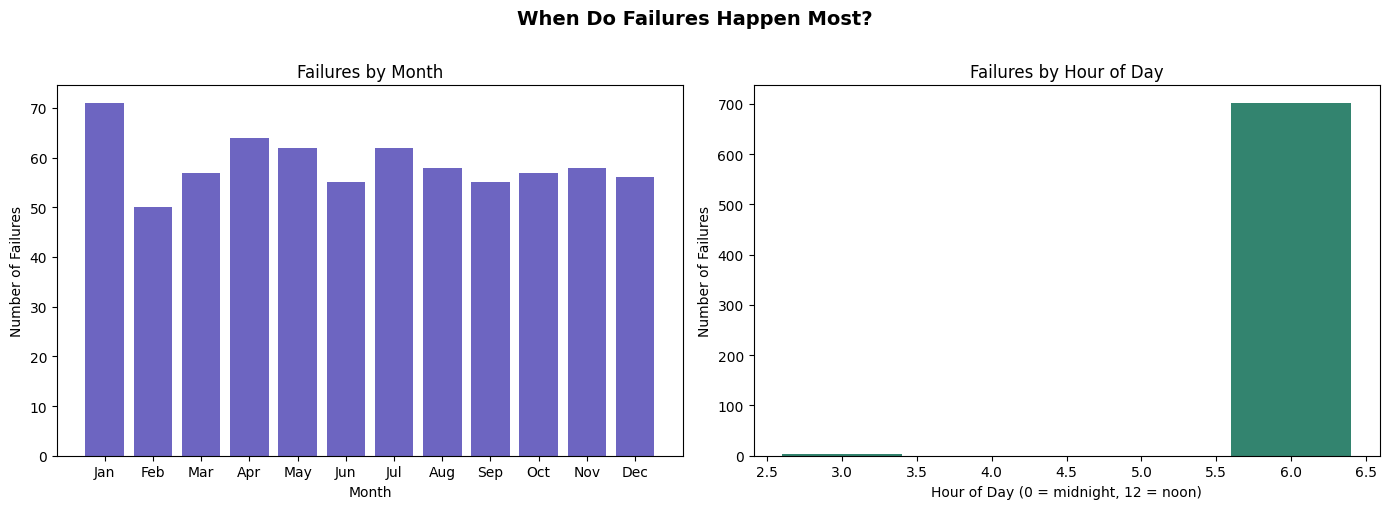

Top 3 months for failures:
  month_name  failure_count
0        Jan             71
3        Apr             64
6        Jul             62

Top 3 hours for failures:
   hour  failure_count
1     6            702
0     3              3


In [ ]:
failures_only = data[data['failure_flag'] == 1].copy()

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly = failures_only.groupby('month').size().reset_index(name='failure_count')
monthly['month_name'] = monthly['month'].map(month_names)

hourly = failures_only.groupby('hour').size().reset_index(name='failure_count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly
axes[0].bar(monthly['month_name'], monthly['failure_count'], color='#534AB7', alpha=0.85)
axes[0].set_title('Failures by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Failures')

# Hourly
axes[1].bar(hourly['hour'], hourly['failure_count'], color='#0F6E56', alpha=0.85)
axes[1].set_title('Failures by Hour of Day')
axes[1].set_xlabel('Hour of Day (0 = midnight, 12 = noon)')
axes[1].set_ylabel('Number of Failures')

plt.suptitle('When Do Failures Happen Most?', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Top 3 months for failures:')
print(monthly.sort_values('failure_count', ascending=False).head(3)[['month_name','failure_count']])
print()
print('Top 3 hours for failures:')
print(hourly.sort_values('failure_count', ascending=False).head(3))

## Step 4.5 — Sensor Behaviour in the Hours Before Failure

**This is the most important analysis.**  
We look at how voltage, rotation, pressure, and vibration change in the **24 hours leading up to a failure**.  
If sensors change before a failure, we can predict it in advance.

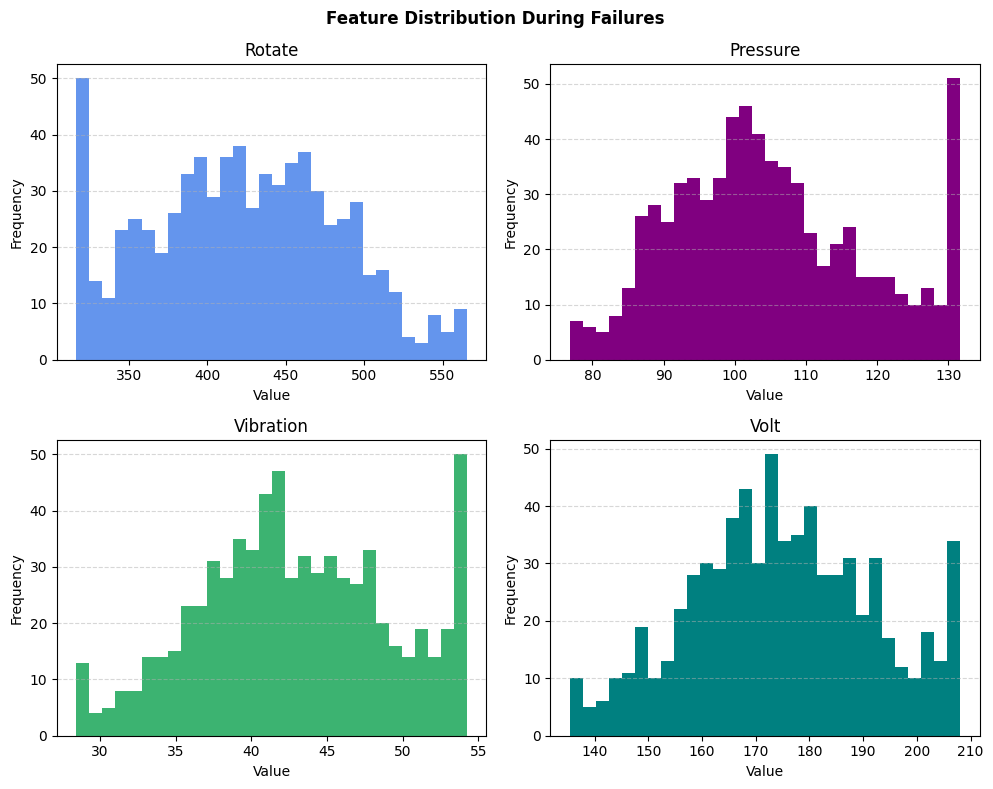

In [ ]:

# Filter only failures
failure_data = data[data['failure_flag'] == 1]

# Subplots (2x2)
fig, ax = plt.subplots(2, 2, figsize=(10,8))

# Rotate
ax[0,0].hist(failure_data['rotate'], bins=30, color='cornflowerblue')
ax[0,0].set_title('Rotate')

# Pressure
ax[0,1].hist(failure_data['pressure'], bins=30, color='purple')
ax[0,1].set_title('Pressure')

# Vibration
ax[1,0].hist(failure_data['vibration'], bins=30, color='mediumseagreen')
ax[1,0].set_title('Vibration')

# Volt
ax[1,1].hist(failure_data['volt'], bins=30, color='teal')
ax[1,1].set_title('Volt')

# Common settings
for a in ax.flat:
    a.set_xlabel('Value')
    a.set_ylabel('Frequency')
    a.grid(axis='y', linestyle='--', alpha=0.5)

# Main title
plt.suptitle('Feature Distribution During Failures', fontweight='bold')

plt.tight_layout()
plt.show()

## STEP 4.6 — MAINTENANCE IMPACT

Does maintenance reduce failure?

/tmp/ipykernel_3118/1042710298.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(maint_bin)['failure_flag'].agg(['count', 'sum'])


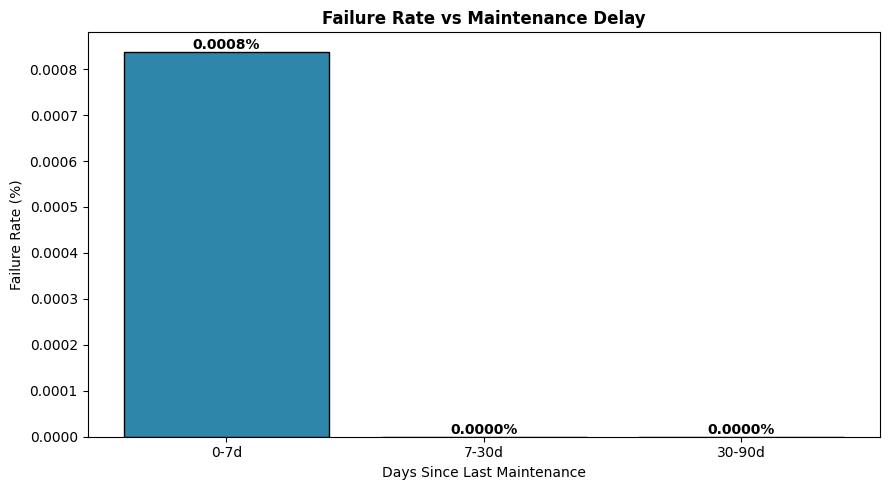

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert seconds to days (no change in data)
days_since_maint = data['time_since_last_maint'] / 86400

# Bins
bins = [0, 7, 30, 90, 180, 10000]
labels = ['0-7d', '7-30d', '30-90d', '90-180d', '180+d']

maint_bin = pd.cut(days_since_maint, bins=bins, labels=labels)

# Group
grouped = data.groupby(maint_bin)['failure_flag'].agg(['count', 'sum'])
failure_rate = (grouped['sum'] / grouped['count']) * 100

# Plot
plt.figure(figsize=(9,5))

colors = ['#2E86AB', '#F6AE2D', '#F26419', '#A23B72', '#1B998B']

bars = plt.bar(
    grouped.index.astype(str),
    failure_rate,
    color=colors,
    edgecolor='black',
    linewidth=1
)

# Add values
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f'{h:.4f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Failure Rate vs Maintenance Delay', fontweight='bold')
plt.xlabel('Days Since Last Maintenance')
plt.ylabel('Failure Rate (%)')

plt.tight_layout()
plt.show()

# Step 4.7 — Failure Rate by Machine Model

**Question:** Are some machine models more reliable than others?  
This tells us if design or build quality plays a role.

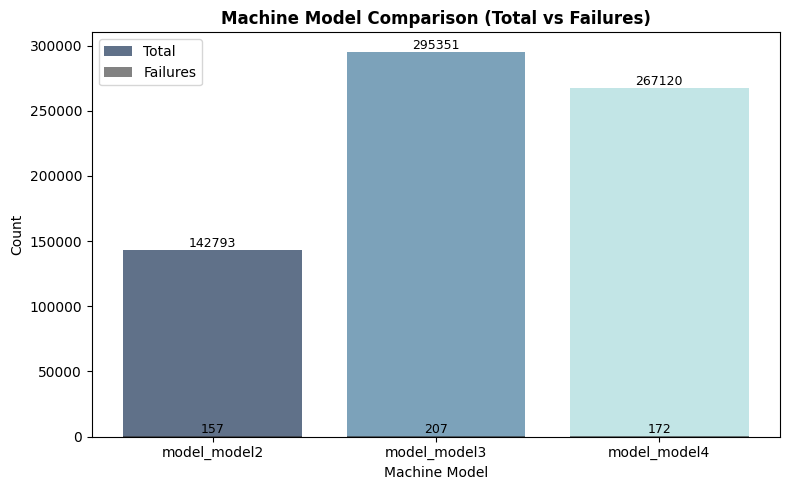

In [ ]:


# Model columns
model_cols = ['model_model2','model_model3','model_model4']

# Total and failures
total = data[model_cols].sum()
failures = data[model_cols].mul(data['failure_flag'], axis=0).sum()

# Plot
plt.figure(figsize=(8,5))

colors = ['#1D3557', '#457B9D', '#A8DADC']
failure_color = '#222222'

# Total bars
plt.bar(total.index, total.values, color=colors, alpha=0.7, label='Total')

# Failure bars (slightly darker overlay)
plt.bar(failures.index, failures.values, color='#2F2F2F', alpha=0.6, label='Failures')

# Labels
for i, col in enumerate(total.index):
    plt.text(i, total[col], int(total[col]), ha='center', va='bottom', fontsize=9)
    plt.text(i, failures[col], int(failures[col]), ha='center', va='bottom', fontsize=9, color='black')

plt.title('Machine Model Comparison (Total vs Failures)', fontweight='bold')
plt.xlabel('Machine Model')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

## Step 4. 8— Which Component Fails the Most?
Question: Among comp1, comp2, comp3, comp4 — which component is responsible for most failures?
This is key for maintenance planning — focus resources on the weakest part.

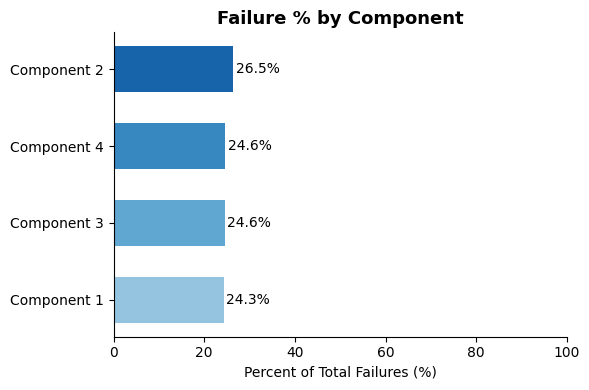

In [ ]:

# 1) Sum failures and calculate percentages
comp = data[['comp1','comp2','comp3','comp4']].sum()
pct = (comp / comp.sum() * 100).sort_values()

# 2) Friendly labels
labels = ['Component 1', 'Component 2', 'Component 3', 'Component 4']
labels = [labels[list(comp.index).index(x)] for x in pct.index]

# 3) Plot
plt.figure(figsize=(6,4))  # medium size
colors = plt.cm.Blues(np.linspace(0.4,0.8,len(pct)))  # soft green-blue gradient
bars = plt.barh(labels, pct.values, color=colors, height=0.6)

# 4) Add labels on bars
for i, v in enumerate(pct):
    plt.text(v+0.5, i, f"{v:.1f}%", va='center')

# 5) Style
plt.title('Failure % by Component', fontsize=13, fontweight='bold')
plt.xlabel('Percent of Total Failures (%)')
plt.xlim(0,100)
plt.grid(False)  # no grid

# Only keep left and bottom axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Step 4.9 Error Types — How Often & How Dangerous
Which Errors Lead to Highest Failure Risk?

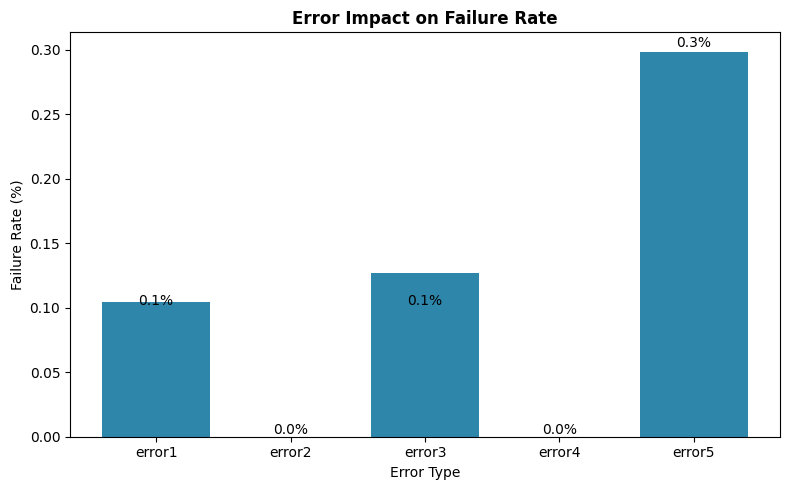

In [ ]:


error_cols = [c for c in data.columns if 'error' in c.lower()]

if error_cols:
    # Failure rate for each error
    fail_rate = [data[data[e] == 1]['failure_flag'].mean() * 100 for e in error_cols]

    plt.figure(figsize=(8,5))

    bars = plt.bar(error_cols, fail_rate, color='#2E86AB')  # nice blue color

    # Add values on bars (rounded to 1 decimal or int style)
    for bar in bars:
        h = round(bar.get_height(), 1)
        plt.text(bar.get_x() + bar.get_width()/2,
                 h,
                 f'{h}%',
                 ha='center',
                 va='bottom',
                 fontsize=10)

    plt.title("Error Impact on Failure Rate", fontweight='bold')
    plt.xlabel("Error Type")
    plt.ylabel("Failure Rate (%)")

    plt.tight_layout()
    plt.show()

else:
    print("No error columns found.")

## Step 4.10 — Deep Correlation: Which Features Link to Failure?

**Question:** Out of all 30+ features, which ones have the strongest relationship with failure?  
We compute the correlation of every numeric feature with `failure_flag` and rank them.  
This tells us exactly which features will be most useful for our ML model in Step 5.

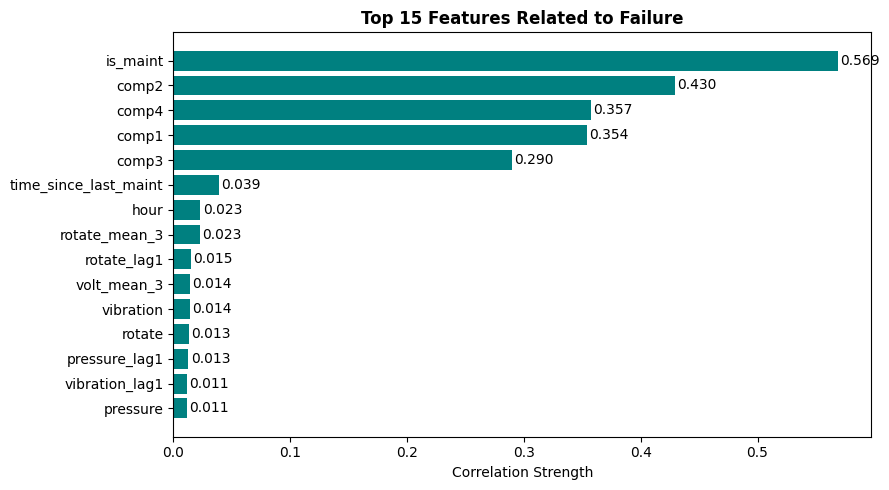

Top 5 predictors: ['is_maint', 'comp2', 'comp4', 'comp1', 'comp3']


In [ ]:

# Select numeric features
num = data.drop(columns=['datetime','machineID'], errors='ignore') \
          .select_dtypes(include=np.number)

# Correlation with failure
corr = num.corr()['failure_flag'].drop('failure_flag').abs()

# Top 15 features
top15 = corr.sort_values(ascending=False).head(15)

# Plot
plt.figure(figsize=(9,5))
plt.barh(top15.index, top15.values, color='teal')

# Add values
for i, v in enumerate(top15.values):
    plt.text(v + 0.002, i, f'{v:.3f}', va='center')

plt.title("Top 15 Features Related to Failure", fontweight='bold')
plt.xlabel("Correlation Strength")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Top 5 predictors
print("Top 5 predictors:", list(top15.head(5).index))

## Step 4.11 Final Summary

The dataset shows that failures are rare events and occur in identifiable patterns across machines, time, sensors, and system components. Certain machines (`machineID`) contribute disproportionately to failures, indicating uneven reliability across the fleet.

Higher values in `vibration`, `pressure`, and `rotate` are consistently linked with failure conditions. Maintenance timing is also important, as failures are more likely when `time_since_last_maint` is high. Error signals (`error1`–`error5`) appear as strong indicators before failure events.

Failures are not evenly distributed over time and show clustering across specific `hour` and `month` values. Component-level analysis (`comp1`–`comp4`) shows that some parts contribute more to system breakdowns than others.

## Key Findings

* Failures are rare compared to normal operation (`failure_flag`)
* Certain `machineID` contribute more to failures
* Sensor readings (`vibration`, `pressure`, `rotate`) are strong indicators
* `time_since_last_maint` influences failure likelihood
* `error1`–`error5` act as early warning signals
* Failures cluster across specific `hour` and `month`
* Components (`comp1–comp4`) have unequal failure contribution
